# Model Extent Polygons (1D, 2D, and Overall Footprints)

HEC-RAS models cover a real footprint on the ground: the perimeters of the 2D flow
areas plus the corridor swept by the 1D cross sections. This notebook shows how to
build those footprints as **true polygons** directly from the geometry HDF, rather
than a rectangular bounding box.

## What you'll learn

- Read 2D flow-area perimeters with `HdfMesh.get_mesh_areas()`.
- Generate 1D river **edge lines** from cross-section end points with
  `HdfXsec.generate_river_edge_lines()` (the pure-Python equivalent of RASMapper's
  *Create Edge Lines at XS Limits*).
- Build the 1D reach **footprint** polygon(s) with `HdfXsec.get_1d_footprint()`.
- Get the **true model extent** polygon (1D + 2D, multipart) from the upgraded
  `HdfProject.get_project_extent(..., geometry_type='footprint')`, and compare it to
  the legacy buffered bounding box.
- Slice the extent into **1D-only** and **2D-only** footprints with the `include_1d`
  / `include_2d` flags.

## Prerequisites

- `ras-commander` with `geopandas` / `shapely` (installed dependencies).
- Internet access on first run (downloads the HEC-RAS example projects).
- No HEC-RAS execution is required — everything is read from the geometry HDF.

In [1]:
import sys
import logging
from pathlib import Path

# Prefer the local repository source so the newest extent APIs are available even
# when an older ras-commander is pip-installed. Walk up from the notebook location
# until we find the package, then put that repo root first on sys.path.
_here = Path.cwd()
for _cand in [_here, *_here.parents]:
    if (_cand / "ras_commander" / "__init__.py").exists():
        sys.path.insert(0, str(_cand))
        break

import matplotlib.pyplot as plt

import ras_commander
from ras_commander import RasExamples, init_ras_project
from ras_commander.hdf import HdfXsec, HdfMesh, HdfProject

# Quiet the library's informational logging so the demo output stays readable.
# (Geometries without 1D cross sections log a handled error while we scan for the
# right one; real failures still raise exceptions.)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

print("ras_commander:", ras_commander.__file__)


def extract_or_reuse(name, suffix):
    """Reuse an already-extracted example project if present, else extract it.

    Keeps notebook re-runs fast; still downloads/extracts on a fresh machine.
    """
    dest = Path.cwd() / "example_projects" / f"{name}_{suffix}"
    if dest.exists() and any(dest.glob("*.prj")):
        return dest
    return RasExamples.extract_project(name, suffix=suffix)


def find_geom_hdfs(project_folder):
    """Return the geometry HDF files (*.g##.hdf) in a project folder, sorted."""
    return sorted(Path(project_folder).glob("*.g[0-9][0-9].hdf"))


def describe(gdf, label):
    """Compact one-line summary of a geometry GeoDataFrame."""
    if gdf is None or len(gdf) == 0:
        print(f"  {label}: (empty)")
        return
    gtypes = sorted(set(gdf.geom_type))
    try:
        area = float(gdf.geometry.area.sum())
    except Exception:
        area = float("nan")
    print(f"  {label}: rows={len(gdf)} types={gtypes} area={area:,.0f} valid={bool(gdf.geometry.is_valid.all())}")

c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ras_commander: H:\CLB-Repos\ras-commander\ras_commander\__init__.py


## Example 1: Combined 1D + 2D model (Bald Eagle Creek Multi-2D)

This model has a 1D river reach *and* several 2D flow areas, so it exercises every
part of the extent API: 2D perimeters, a 1D reach footprint, and the unified overall
extent.

In [2]:
project = extract_or_reuse("BaldEagleCrkMulti2D", "extent_demo")
ras = init_ras_project(project, "6.6")

# Pick the geometry HDF that carries both 2D areas and 1D cross sections.
geom_hdf = None
for candidate in find_geom_hdfs(project):
    names = HdfMesh.get_mesh_area_names(candidate)
    xs = HdfXsec.get_cross_sections(candidate)
    if names and not xs.empty:
        geom_hdf = candidate
        break
geom_hdf = geom_hdf or find_geom_hdfs(project)[0]
print("Geometry HDF:", geom_hdf.name)
print("2D area names:", HdfMesh.get_mesh_area_names(geom_hdf))

Geometry HDF: BaldEagleDamBrk.g06.hdf


2D area names: ['193', '194', 'LockHaven']


### 2D flow-area perimeters

`HdfMesh.get_mesh_areas()` returns one perimeter polygon per 2D flow area, already
carrying the project CRS. Multiple areas become multiple rows.

In [3]:
mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
print("CRS:", mesh_areas.crs)
describe(mesh_areas, "2D perimeters (per area)")
mesh_areas[["mesh_name", "geometry"]]

CRS: EPSG:2271
  2D perimeters (per area): rows=3 types=['Polygon'] area=172,401,558 valid=True


,mesh_name,geometry
0,193,"POLYGON ((2042744.054 340037.055, 2042059.203 ..."
1,194,"POLYGON ((2013482.56 332510.738, 2013482.172 3..."
2,LockHaven,"POLYGON ((2045454.816 349795.754, 2045592.698 ..."


### 1D edge lines and the reach footprint

The 1D footprint is the corridor between the left and right **edge lines**, closed at
each end by the upstream and downstream cross sections. If the geometry already stores
`Geometry/River Edge Lines`, those are used; otherwise `get_1d_footprint()` generates
them on the fly from the cross-section end points (`generate_river_edge_lines()`).

In [4]:
stored_edges = HdfXsec.get_river_edge_lines(geom_hdf)
generated_edges = HdfXsec.generate_river_edge_lines(geom_hdf)
describe(stored_edges, "stored edge lines")
describe(generated_edges, "generated edge lines (fallback)")

# Per-reach footprint polygons, and the dissolved (multipart) version.
footprint_1d = HdfXsec.get_1d_footprint(geom_hdf, dissolve=False)
footprint_1d_dissolved = HdfXsec.get_1d_footprint(geom_hdf, dissolve=True)
describe(footprint_1d, "1D footprint (per reach)")
describe(footprint_1d_dissolved, "1D footprint (dissolved)")
footprint_1d[["River", "Reach", "source", "geometry"]]

  stored edge lines: (empty)
  generated edge lines (fallback): rows=2 types=['LineString'] area=0 valid=True


  1D footprint (per reach): rows=1 types=['Polygon'] area=707,347,872 valid=True
  1D footprint (dissolved): rows=1 types=['Polygon'] area=707,347,872 valid=True


,River,Reach,source,geometry
0,Bald Eagle Cr.,Lock Haven,generated_edge_lines,"POLYGON ((1966056.938 291992.687, 1966305.15 2..."


### The overall model extent (upgraded `get_project_extent`)

`HdfProject.get_project_extent(..., geometry_type='footprint')` (the new default)
unions the 2D perimeters with the 1D reach footprints into the true model extent.
Pass `buffer_percent=0` for the raw footprint. The `include_1d` / `include_2d` flags
carve out the 1D-only and 2D-only extents. For comparison, `geometry_type='bbox'`
returns the legacy buffered bounding box.

In [5]:
overall, overall_bounds = HdfProject.get_project_extent(geom_hdf, buffer_percent=0.0)
extent_1d_only, _ = HdfProject.get_project_extent(geom_hdf, include_2d=False, buffer_percent=0.0)
extent_2d_only, _ = HdfProject.get_project_extent(geom_hdf, include_1d=False, buffer_percent=0.0)
bbox, bbox_bounds = HdfProject.get_project_extent(geom_hdf, geometry_type="bbox", buffer_percent=50.0)

describe(overall, "overall footprint (1D + 2D)")
describe(extent_1d_only, "1D-only extent")
describe(extent_2d_only, "2D-only extent")
describe(bbox, "legacy bbox (buffered 50%)")

overall_area = float(overall.geometry.area.sum())
bbox_area = float(bbox.geometry.area.sum())
print(f"\nThe true footprint is {bbox_area / overall_area:.1f}x smaller than the bounding box.")

# Sanity checks (the notebook doubles as a functional test).
assert not overall.empty and overall.geometry.is_valid.all()
assert extent_2d_only.geometry.iloc[0].geom_type in ("Polygon", "MultiPolygon")
assert overall_area <= bbox_area
print("\nChecks passed.")

  overall footprint (1D + 2D): rows=1 types=['Polygon'] area=879,576,333 valid=True
  1D-only extent: rows=1 types=['Polygon'] area=707,347,872 valid=True
  2D-only extent: rows=1 types=['MultiPolygon'] area=172,401,558 valid=True
  legacy bbox (buffered 50%): rows=1 types=['Polygon'] area=15,282,299,978 valid=True

The true footprint is 17.4x smaller than the bounding box.

Checks passed.


C:\Users\bill\AppData\Local\Temp\ipykernel_22576\1033842093.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", fontsize=8)


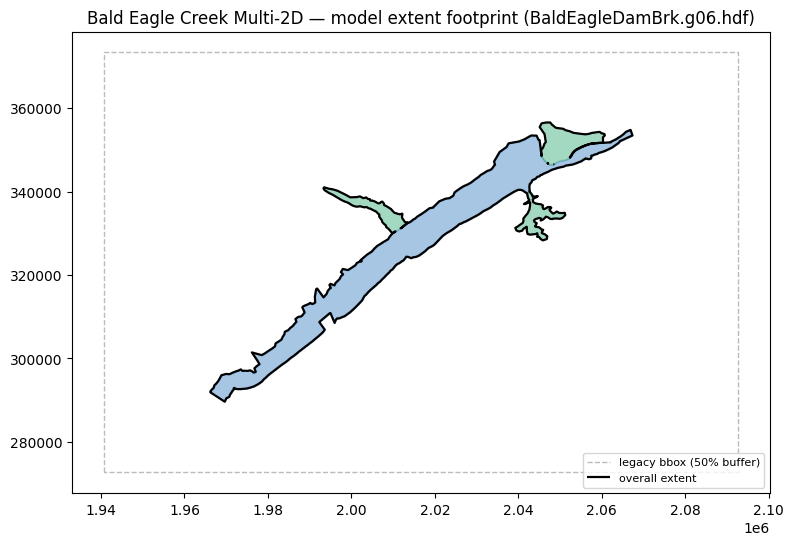

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
bbox.boundary.plot(ax=ax, color="#bbb", linestyle="--", linewidth=1.0, label="legacy bbox (50% buffer)")
footprint_1d.plot(ax=ax, color="#3b82c4", alpha=0.45, edgecolor="#3b82c4", label="1D reach footprint")
mesh_areas.plot(ax=ax, color="#33aa77", alpha=0.45, edgecolor="#33aa77", label="2D flow areas")
overall.boundary.plot(ax=ax, color="black", linewidth=1.6, label="overall extent")
ax.set_title(f"Bald Eagle Creek Multi-2D — model extent footprint ({geom_hdf.name})")
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=8)
plt.show()

## Example 2: 2D model (Muncie)

Muncie stores its 2D mesh in a specific geometry. Here we locate the geometry that
actually contains a 2D flow area, extract its perimeter, and confirm the 2D-only and
combined footprints. This shows the extent API on a mesh-driven model with a real
projected CRS (Indiana State Plane).

In [7]:
muncie = extract_or_reuse("Muncie", "extent_demo")
init_ras_project(muncie, "6.6")

muncie_geom = None
for candidate in find_geom_hdfs(muncie):
    if HdfMesh.get_mesh_area_names(candidate):
        muncie_geom = candidate
        break
print("Muncie 2D geometry:", muncie_geom.name)

muncie_mesh = HdfMesh.get_mesh_areas(muncie_geom)
muncie_2d_only, _ = HdfProject.get_project_extent(muncie_geom, include_1d=False, buffer_percent=0.0)
muncie_full, _ = HdfProject.get_project_extent(muncie_geom, buffer_percent=0.0)
print("CRS:", muncie_mesh.crs.name if muncie_mesh.crs else None)
describe(muncie_mesh, "2D perimeter")
describe(muncie_2d_only, "2D-only extent")
describe(muncie_full, "full footprint (1D + 2D)")

assert not muncie_2d_only.empty and muncie_2d_only.geometry.is_valid.all()
print("\nChecks passed.")

Muncie 2D geometry: Muncie.g02.hdf


CRS: NAD83 / Indiana East (ftUS)
  2D perimeter: rows=1 types=['Polygon'] area=13,709,793 valid=True
  2D-only extent: rows=1 types=['Polygon'] area=13,709,793 valid=True
  full footprint (1D + 2D): rows=1 types=['Polygon'] area=25,371,659 valid=True

Checks passed.


C:\Users\bill\AppData\Local\Temp\ipykernel_22576\2550234105.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


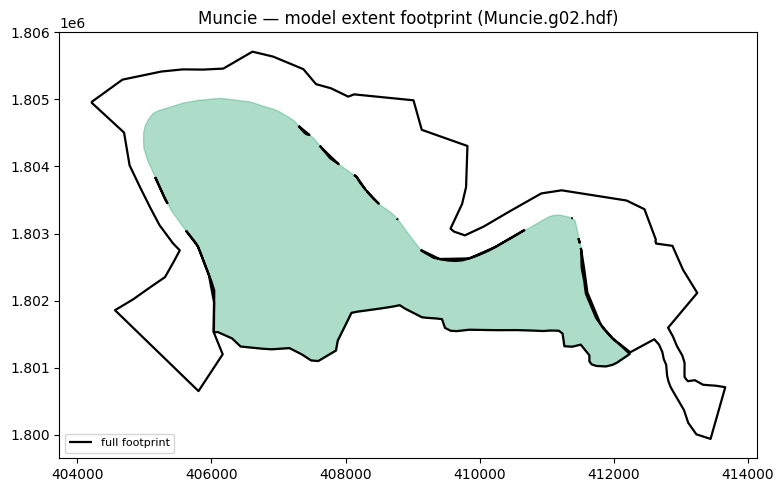

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
muncie_mesh.plot(ax=ax, color="#33aa77", alpha=0.4, edgecolor="#33aa77", label="2D flow area")
muncie_full.boundary.plot(ax=ax, color="black", linewidth=1.6, label="full footprint")
ax.set_title(f"Muncie — model extent footprint ({muncie_geom.name})")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8)
plt.show()

## Key takeaways

- **`HdfProject.get_project_extent(geometry_type='footprint')`** returns the true model
  extent polygon (1D reach footprints + 2D perimeters), replacing the old
  bounding-box-only behavior. Use `geometry_type='bbox'` for the legacy buffered box
  (still used internally for precipitation/terrain download windows).
- **`include_1d` / `include_2d`** slice the extent into 1D-only or 2D-only footprints;
  multiple areas or reaches produce a multipart polygon.
- **`HdfXsec.get_1d_footprint()`** builds the 1D corridor from river edge lines, and
  **`HdfXsec.generate_river_edge_lines()`** derives those edge lines from cross-section
  end points when the model has none stored.
- Pass **`buffer_percent=0`** for the raw footprint; a positive value buffers it outward.

### Adapting for your project

```python
from ras_commander.hdf import HdfProject

footprint, bounds = HdfProject.get_project_extent("MyModel.g01.hdf", buffer_percent=0.0)
footprint.to_file("model_extent.geojson", driver="GeoJSON")  # or .gpkg / .shp
```